In [90]:
import duckdb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import re
from sklearn.preprocessing import StandardScaler


con = duckdb.connect('capillary.db')

df = con.execute(""" 
                 SELECT id, value, pid,delimit_value, delimit_value2,analysis, protein_value, label, interpretation
                 FROM protein_data 
                 WHERE value IS NOT NULL
                 AND (label = 0 OR label = 1 )
                 AND delimit_value IS NOT NULL
                 AND delimit_value2 IS NOT NULL
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()

pids = con.execute("SELECT DISTINCT pid FROM protein_data WHERE label = 0 OR label = 1").df()


con.close()


def extract_fractions(delimit_list):
    fractions = []
    for item in delimit_list:
        match = re.search(r'(\d+\.?\d*)\s*%', str(item))
        if match:
            fractions.append(float(match.group(1)))
    return fractions

def extract_relevant_values(analysis_list: list[str], value_list: list[str], relevant: list[str]) -> np.array:
    protein_values = np.array([np.nan]*len(relevant))
    mapping = dict()

    if len(analysis_list) > len(value_list):
        raise Exception("Analysis list and value list must be of same length!")
    
    for i in range(len(analysis_list)):
        analysis = analysis_list[i].replace('*','')
        value = clean_value(value_list[i])
        mapping.update({analysis: value})

    for (i, analysis) in enumerate(relevant):
        protein_values[i] = mapping.get(analysis,np.nan)

    #får vi en nan får vi tyvärr hoppa över hela raden, jag kör pd.dropna senare
    if sum( (np.isnan(protein_values) == True) ) > 0:
        return np.nan

    return protein_values


def clean_value(val: str) -> float:
    if val is None or val == '' or val == 'NA' or val == 'NEG':
        return np.nan
    try:
        return float(str(val).replace('<', '').replace('>', '').strip())
    except:
        return np.nan
    

#hämta ut protein-value
relevant_anlysis = ['0054','0055','0056','0058','0062','0064','0065','0066']
df['protein_value'] = df.apply(
    lambda row: extract_relevant_values(
        row['analysis'], 
        row['protein_value'], 
        relevant_anlysis
    ), 
    axis=1
)


#value
df = df[ df['value'].apply(len) == 301 ] #vaska de rader där value inte har rätt längd (typ bara en korrupt rad)
df['value'] = df['value'].apply(lambda x: x[:300])

#delimit_value
df['delimit_value'] = df['delimit_value'].apply(extract_fractions)
df = df[ df['delimit_value'].apply(len) == 6]

#delimit_value2
df = df[ df['delimit_value2'].apply(len) == 15]

#protein_value
df = df.dropna()


X_curve     = np.array(df['value'].tolist(),         dtype=np.float32)  # (n, 300)
X_fractions = np.array(df['delimit_value'].tolist(),  dtype=np.float32)  # (n, 6)
X_delimit2  = np.array(df['delimit_value2'].tolist(), dtype=np.float32)  # (n, 15)
X_protein   = np.array(df['protein_value'].tolist(),  dtype=np.float32)  # (n, 8)


X = np.concatenate([X_curve, X_fractions, X_delimit2,X_protein], axis=1)  # (n, 329)
y = np.array(df['label'].values, dtype=np.int64)


print(X.shape) 
print(y.shape)  

# Kolla att det inte finns NaN eller inf
print(f"NaN: {np.isnan(X).sum()}")
print(f"Inf: {np.isinf(X).sum()}")

# Kolla klassbalansen
unique, counts = np.unique(y, return_counts=True)
for val, count in zip(unique, counts):
    print(f"Label {val}: {count} ({count/len(y)*100:.1f}%)")



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(131578, 329)
(131578,)
NaN: 0
Inf: 0
Label 0: 114295 (86.9%)
Label 1: 17283 (13.1%)


In [ ]:
valtrain_pids, test_pids = train_test_split(pids, test_size=0.15,random_state=25)
train_pids, val_pids = train_test_split(valtrain_pids, test_size=0.15,random_state=25)

test_rows = df[ df['pid'].isin(test_pids['pid'].tolist()) ]
val_rows = df[ df['pid'].isin(val_pids['pid'].tolist()) ]
train_rows = df[ df['pid'].isin(train_pids['pid'].tolist()) ]


id_train = train_rows['id'].to_numpy()
id_val   = val_rows['id'].to_numpy()
id_test  = test_rows['id'].to_numpy()


print(f"Antal fall med M-komponent i träningsdatan:{(train_rows['label'] == 1).sum()}")
print(f"Antal fall utan M-komponent i träningsdatan:{(train_rows['label'] == 0).sum()}")
print(f"Antal fall med M-komponent i testdatan:{(test_rows['label'] == 1).sum()}")
print(f"Antal fall utan M-komponent i testdatan:{(test_rows['label'] == 0).sum()}")

X_train = np.concatenate([np.array(train_rows['value'].tolist(), dtype=np.float32),
                           np.array(train_rows['delimit_value'].tolist(), dtype=np.float32),
                           np.array(train_rows['delimit_value2'].tolist(), dtype=np.float32),
                           np.array(train_rows['protein_value'].to_list(),dtype=np.float32)
                           ], axis=1)

X_val   = np.concatenate([np.array(val_rows['value'].tolist(), dtype=np.float32),
                           np.array(val_rows['delimit_value'].tolist(), dtype=np.float32),
                           np.array(val_rows['delimit_value2'].tolist(), dtype=np.float32),
                           np.array(val_rows['protein_value'].to_list(),dtype=np.float32)], axis=1)

X_test  = np.concatenate([np.array(test_rows['value'].tolist(), dtype=np.float32),
                           np.array(test_rows['delimit_value'].tolist(), dtype=np.float32),
                           np.array(test_rows['delimit_value2'].tolist(), dtype=np.float32),
                           np.array(test_rows['protein_value'].to_list(),dtype=np.float32)], axis=1)

y_train = np.array(train_rows['label'].values, dtype=np.int64)
y_val   = np.array(val_rows['label'].values,   dtype=np.int64)
y_test  = np.array(test_rows['label'].values,  dtype=np.int64)

scaler = StandardScaler()
X_train[:, 300:] = scaler.fit_transform(X_train[:, 300:])
X_val[:, 300:]   = scaler.transform(X_val[:, 300:])
X_test[:, 300:]  = scaler.transform(X_test[:, 300:])

X_train = torch.tensor(X_train)
X_val   = torch.tensor(X_val)
X_test  = torch.tensor(X_test)
y_train = torch.tensor(y_train)
y_val   = torch.tensor(y_val)
y_test  = torch.tensor(y_test)

print(f"Träning:    {len(X_train):>6} ({len(X_train)/len(df):.0%})")
print(f"Validering: {len(X_val):>6} ({len(X_val)/len(df):.0%})")
print(f"Test:       {len(X_test):>6} ({len(X_test)/len(df):.0%})")

Antal fall med M-komponent i träningsdatan:12338
Antal fall utan M-komponent i träningsdatan:82688
Antal fall med M-komponent i testdatan:2569
Antal fall utan M-komponent i testdatan:17142
Träning:     95026 (72%)
Validering:  16841 (13%)
Test:        19711 (15%)


In [92]:
batch_sz = 512

# DataLoaders
train_dataloader = DataLoader(
    TensorDataset(X_train, y_train, torch.tensor(id_train)),
    batch_size=batch_sz,
    shuffle=True
)

val_dataloader = DataLoader(
    TensorDataset(X_val, y_val, torch.tensor(id_val)),
    batch_size=batch_sz
)

test_dataloader = DataLoader(
    TensorDataset(X_test, y_test, torch.tensor(id_test)),
    batch_size=batch_sz
)

for X, y,_ in val_dataloader:
    print(f"Shape of X: {X.shape}")
    print(f"Shape of y: {y.shape}")
    break

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

# Define model
class CNNNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_channels=1,out_channels=32,kernel_size=7,padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32,64,kernel_size=5,padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64,128,kernel_size=3,padding=1),
            nn.ReLU()
        )

        self.gap = nn.AdaptiveAvgPool1d(1)

        self.classifier = nn.Sequential(
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64,2)
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        x = self.features(x)
        x = self.gap(x)
        x = torch.flatten(x,1)
        x = self.classifier(x)
        return x

class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # ENCODER
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 8, kernel_size=7, stride=2, padding=3), # 300 -> 150
            nn.ReLU(),
            nn.Conv1d(8, 16, kernel_size=5, stride=2, padding=2), # 150 -> 75
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, stride=2, padding=1), # 75 -> 38
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32 * 38, 16) # Bottleneck
        )
        
        # DECODER
        self.decoder = nn.Sequential(
            nn.Linear(16, 32 * 38),
            nn.ReLU(),
            nn.Unflatten(1, (32, 38)),
            nn.ConvTranspose1d(32, 16, 3, stride=2, padding=1, output_padding=0), # 38 -> 75
            nn.ReLU(),
            nn.ConvTranspose1d(16, 8, 5, stride=2, padding=2, output_padding=1), # 75 -> 150
            nn.ReLU(),
            nn.ConvTranspose1d(8, 1, 7, stride=2, padding=3, output_padding=1),  # 150 -> 300
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        z = self.encoder(x)
        out = self.decoder(z)
        return out.squeeze(1)


CNNModel = CNNNetwork().to(device)
AutoEncoderModel = Autoencoder().to(device)
CNNModel.load_state_dict(torch.load("networks/convolution_model.pth", weights_only=True))
AutoEncoderModel.load_state_dict(torch.load("networks/auto_encoder_model.pth", weights_only=True))

Shape of X: torch.Size([512, 329])
Shape of y: torch.Size([512])
Using mps device


<All keys matched successfully>

In [ ]:
##Prediktioner mha auto-encodern
import joblib
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

def get_autoencoder_reconstructions( X_data, batch_size=512):
    AutoEncoderModel.eval()
    reconstructions = []
    X_tensor = torch.tensor(X_data, dtype=torch.float32)

    dataset = TensorDataset(X_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    with torch.no_grad():
        for batch in loader:
            inputs = batch[0].to(device)
            outputs = AutoEncoderModel(inputs)
            reconstructions.append(outputs.cpu().numpy())
            
    # Slå ihop alla batchar till en enda matris (N, 300)
    return np.concatenate(reconstructions, axis=0).squeeze()

#hitta prediktionerna från andra modellen
def predict_cnn(X_data, batch_size=512):
    CNNModel.eval()
    all_probs = []
    X_tensor = torch.tensor(X_data, dtype=torch.float32)
    dataset = TensorDataset(X_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for batch in loader:
            inputs = batch[0].to(device)
            logits = CNNModel(inputs)
            probs = torch.softmax(logits, dim=1)[:, 1]  # sannolikhet för positivt
            all_probs.append(probs.cpu().numpy())
            
    return np.concatenate(all_probs)

train_rows['cnn_probs'] = predict_cnn(X_train)

X_curves = np.stack(train_rows['value'])
reconstructions = get_autoencoder_reconstructions(X_curves)

errors = X_curves - reconstructions
squared_errors = np.power((X_curves-reconstructions),2)

train_rows['reconstructions'] = list(reconstructions)
train_rows['errors'] = list(errors)
train_rows['squared_errors'] = list(squared_errors)
train_rows['total_squared_error'] = train_rows['squared_errors'].apply(np.sum) / 1000
train_rows['total_squared_error_gamma_region'] = train_rows['squared_errors'].apply(lambda x: np.sum(x[200:270])) / 1000
print(f"minimal TSE: {np.min(train_rows['total_squared_error'])} | maximal TSE: {np.max(train_rows['total_squared_error'])} | average TSE: {np.mean(train_rows['total_squared_error'])}")

print(f"Gamma region: minimal TSE: {np.min(train_rows['total_squared_error_gamma_region'])} | maximal TSE: {np.max(train_rows['total_squared_error_gamma_region'])} | average TSE: {np.mean(train_rows['total_squared_error_gamma_region'])}")

model = joblib.load('networks/logistic_regression.pkl')
log_probabilities = model.predict_proba(np.array(train_rows['total_squared_error_gamma_region']).reshape(-1,1))
train_rows['encoder_probabilities'] = log_probabilities[:,1]


minimal TSE: 5.524497755126851 | maximal TSE: 79605.55559003257 | average TSE: 787.9052282309432
Gamma region: minimal TSE: 0.24223792273903383 | maximal TSE: 69354.7399479172 | average TSE: 517.8452279341057


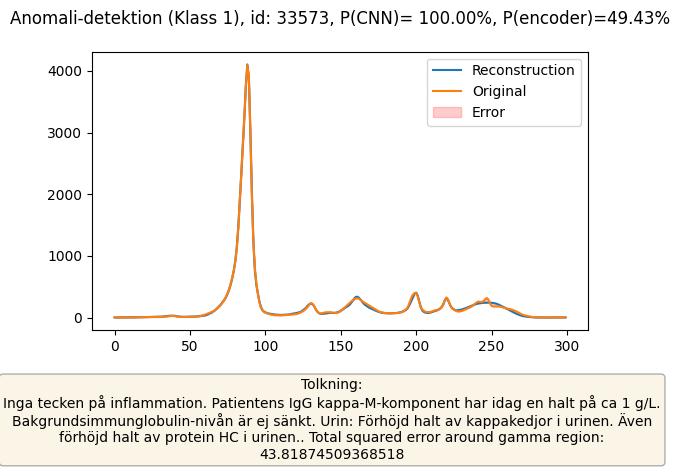

In [43]:
## Sammantaget!
sorted = train_rows.sort_values('total_squared_error_gamma_region').reset_index(drop=True)
idx = 5000

subset = sorted[sorted['label'] == 1]
idx = subset['total_squared_error_gamma_region'].nsmallest(10000).index[2000] #här kan man plocka outliers

cnn_probability = sorted.loc[idx,'cnn_probs']
encoder_probability = sorted.loc[idx,'encoder_probabilities']

plt.figure()
# 2. Skapa ett "subplot"-system som lämnar tomrum längst ner
# .subplots_adjust gör att vi manuellt kan dra upp bottenkanten på grafen
plt.title(f"Anomali-detektion (Klass {sorted.loc[idx,'label']}), id: {sorted.loc[idx,'id']}, P(CNN)= {cnn_probability*100:.2f}%, P(encoder)={encoder_probability*100:.2f}%", pad=20)
plt.subplots_adjust(bottom=0.3,hspace=0.3) 

plt.plot(sorted.loc[idx,'reconstructions'], label='Reconstruction', linewidth=1.5)
plt.plot(sorted.loc[idx,'value'], label='Original', linewidth=1.5)
plt.fill_between(range(300), sorted.loc[idx,'value'], sorted.loc[idx,'reconstructions'], color='red', alpha=0.2, label='Error')

plt.legend()


# Hämta ren text
tolkning_text = sorted.loc[idx,'interpretation'] + ". Total squared error around gamma region: " + str(sorted.loc[idx,'total_squared_error_gamma_region'])

# 3. Använd y-koordinat som är lägre (t.ex. 0.15) och sätt va='top'
# wrap=True fungerar bäst om vi anger en bredd för texten (width)
plt.figtext(0.5, 0.20, f"Tolkning:\n{tolkning_text}", 
            wrap=True, 
            horizontalalignment='center', 
            verticalalignment='top',
            fontsize=10, 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.show()
    

In [89]:

from sklearn.metrics import classification_report, confusion_matrix

threshold_cnn = 0.25
threshold_encoder = 0.25


predictions = (train_rows['cnn_probs'] >= threshold_cnn) | (train_rows['encoder_probabilities'] >= threshold_encoder)

train_rows['prob_product'] = np.multiply(train_rows['cnn_probs'],train_rows['encoder_probabilities'])

accuracy = sum(predictions == train_rows['label'])/len(predictions)

false_negatives = sum( (train_rows['label'] == 1) & (predictions == 0))/sum(train_rows['label'] == 1)
false_positives = sum( (train_rows['label'] == 0) & (predictions == 1))/sum(train_rows['label'] == 0)
false_negative_by_total = sum( (train_rows['label'] == 1) & (predictions == 0))/len(predictions)
false_positive_by_total = sum( (train_rows['label'] == 0) & (predictions == 1))/len(predictions)


# Hitta FN
fn_idx = np.where((train_rows['label'] == 1) & (predictions == 0))[0]

print(f"Antal FN: {len(fn_idx)}")
# Rapport
print(classification_report(train_rows['label'], predictions, target_names=['Negativ', 'Positiv']))
print(confusion_matrix(train_rows['label'], predictions))

print(f"Overall accuracy (using threshold): {100*accuracy:.2f}%")
print(f"False negative rate, i.e dangerous percentage (using threshold): {100*false_negatives:.2f}%")
print(f"False positive rate, i.e unneccesary alarm (using threshold): {100*false_positives:.2f}%")
print(f"% of all cases where a positive case was missed: {100*false_negative_by_total:.2f}%")
print(f"% of all cases where a negative case was incorrectly flagged as positive: {100*false_positive_by_total:.2f}%")




Antal FN: 87
              precision    recall  f1-score   support

     Negativ       1.00      0.98      0.99     82852
     Positiv       0.87      0.99      0.93     12791

    accuracy                           0.98     95643
   macro avg       0.93      0.98      0.96     95643
weighted avg       0.98      0.98      0.98     95643

[[80913  1939]
 [   87 12704]]
Overall accuracy (using threshold): 97.88%
False negative rate, i.e dangerous percentage (using threshold): 0.68%
False positive rate, i.e unneccesary alarm (using threshold): 2.34%
% of all cases where a positive case was missed: 0.09%
% of all cases where a negative case was incorrectly flagged as positive: 2.03%


No. false negatives: 1525


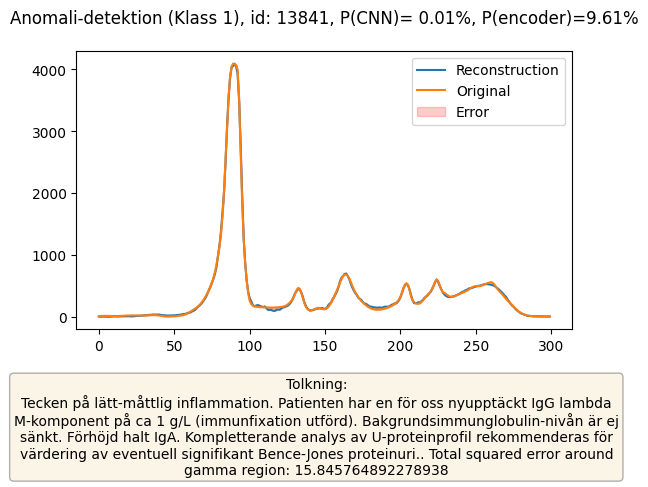

In [88]:
## Sammantaget!
sorted = train_rows.sort_values('prob_product').reset_index(drop=True)
idx = 5000

subset = sorted[sorted['label'] == 0]
false_negative_idx = ((sorted['cnn_probs'] < threshold_cnn) | (sorted['encoder_probabilities'] < threshold_encoder) ) & (sorted['label'] == 1)

print(f"No. false negatives: {np.sum(false_negative_idx)}")
false_negatives = sorted[false_negative_idx]

idx = subset['prob_product'].nlargest(1000).index[6] #här kan man plocka outliers
idx = false_negatives.index[14]

cnn_probability = sorted.loc[idx,'cnn_probs']
encoder_probability = sorted.loc[idx,'encoder_probabilities']

plt.figure()
plt.title(f"Anomali-detektion (Klass {sorted.loc[idx,'label']}), id: {sorted.loc[idx,'id']}, P(CNN)= {cnn_probability*100:.2f}%, P(encoder)={encoder_probability*100:.2f}%", pad=20)
plt.subplots_adjust(bottom=0.3,hspace=0.3) 

plt.plot(sorted.loc[idx,'reconstructions'], label='Reconstruction', linewidth=1.5)
plt.plot(sorted.loc[idx,'value'], label='Original', linewidth=1.5)
plt.fill_between(range(300), sorted.loc[idx,'value'], sorted.loc[idx,'reconstructions'], color='red', alpha=0.2, label='Error')

plt.legend()


# Hämta ren text
tolkning_text = sorted.loc[idx,'interpretation'] + ". Total squared error around gamma region: " + str(sorted.loc[idx,'total_squared_error_gamma_region'])

# 3. Använd y-koordinat som är lägre (t.ex. 0.15) och sätt va='top'
# wrap=True fungerar bäst om vi anger en bredd för texten (width)
plt.figtext(0.5, 0.20, f"Tolkning:\n{tolkning_text}", 
            wrap=True, 
            horizontalalignment='center', 
            verticalalignment='top',
            fontsize=10, 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.show()
    

In [83]:
false_negative_idx_cnn = (sorted['cnn_probs'] < threshold_cnn)  & (sorted['label'] == 1)
false_negative_idx_aed = (sorted['encoder_probabilities'] < threshold_encoder)  & (sorted['label'] == 1)
overlap = (false_negative_idx_cnn & false_negative_idx_aed)
print(f"totala falska negativa med CNN: {sum(false_negative_idx_cnn)}")
print(f"totala falska negativa med encoder: {sum(false_negative_idx_aed)}")
print(f"totala falska negativa med överlap: {sum(overlap)}")





totala falska negativa med CNN: 117
totala falska negativa med encoder: 1495
totala falska negativa med överlap: 87
